In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\nice\Desktop\projects\Customer-Support\Data\Scraped_data\github_issues.csv")

In [3]:
df

,title,body,label
0,Crashing 10 times and vasting the premium requ...,"\nType: <b>Bug</b>\n\nAh yes, truly impressive...",chat-billing
1,Potential Premium Model Limit Bypass via Model...,I observed a potential issue with premium mode...,chat-billing
2,[Unhandled Error] Uncaught TypeError: Cannot r...,## Error Message\n```\nUncaught TypeError: Can...,bug
3,ABUSE??? Potential Premium Model Limit Bypass ...,I observed a potential issue with premium mode...,chat-billing
4,Rate limiting during normal use,\nType: <b>Bug</b>\n\nnormal use with copilot ...,new release
...,...,...,...
4909,Chat took too long to get ready.,\nType: <b>Performance Issue</b>\n\nChat took ...,*duplicate
4910,Chat took too long to get ready.,\nType: <b>Performance Issue</b>\n\nChat took ...,info-needed
4911,Integrated browser is rendered on top of sideb...,Testing #290493\n\n* I opened up a simple brow...,bug
4912,Not getting a pop-up for automatic tasks,Testing #290461\n\n* I created a tasks.json fi...,info-needed


In [4]:
df["label"].value_counts()

label
info-needed               1721
bug                        829
spam                       498
duplicate                  298
triage-needed              263
                          ... 
inline-chat-affordance       1
markdown                     1
telemetry                    1
~chat-request-failed         1
suggest                      1
Name: count, Length: 86, dtype: int64

In [5]:
df.isna().sum()

title     2
body     67
label     0
dtype: int64

In [6]:
df.duplicated().sum()

321

In [7]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [8]:
df["label"] = df["label"].str.replace("*", "", regex=False)
df["label"]=df["label"].str.replace("~", " ", regex=False)
df["label"]=df["label"].str.strip()
df["label"]=df["label"].str.lower()

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
df["label"].value_counts()

label
info-needed               1621
bug                        819
duplicate                  493
spam                       346
triage-needed              243
                          ... 
on-testplan                  1
model-byok                   1
inline-chat-affordance       1
markdown                     1
chat-agent-editing           1
Name: count, Length: 81, dtype: int64

<Figure size 1000x500 with 0 Axes>

In [10]:
df.loc[df["label"]=="triage-needed"]

,title,body,label
38,VS Code prepend PATH environment variable with...,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,triage-needed
40,WTF? This just created itself. I'm not sure ...,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,triage-needed
113,AI suggestions still showing even if I turn th...,Why would it autopost on github...,triage-needed
123,bug reported,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,triage-needed
124,bug report,<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,triage-needed
...,...,...,...
4764,boolean expressions are true or false?,\nType: <b>Bug</b>\n\nWhy add ? true : false t...,triage-needed
4839,Code completion bug,\nType: <b>Bug</b>\n\n# Description\nCode comp...,triage-needed
4840,"Extensions that handle cursor movement, text m...",<!-- ⚠️⚠️ Do Not Delete This! bug_report_templ...,triage-needed
4865,Loop infinito en error al compilar.,ADD ISSUE DESCRIPTION HERE\n\nVersion: 1.108.2...,triage-needed


<Axes: xlabel='label'>

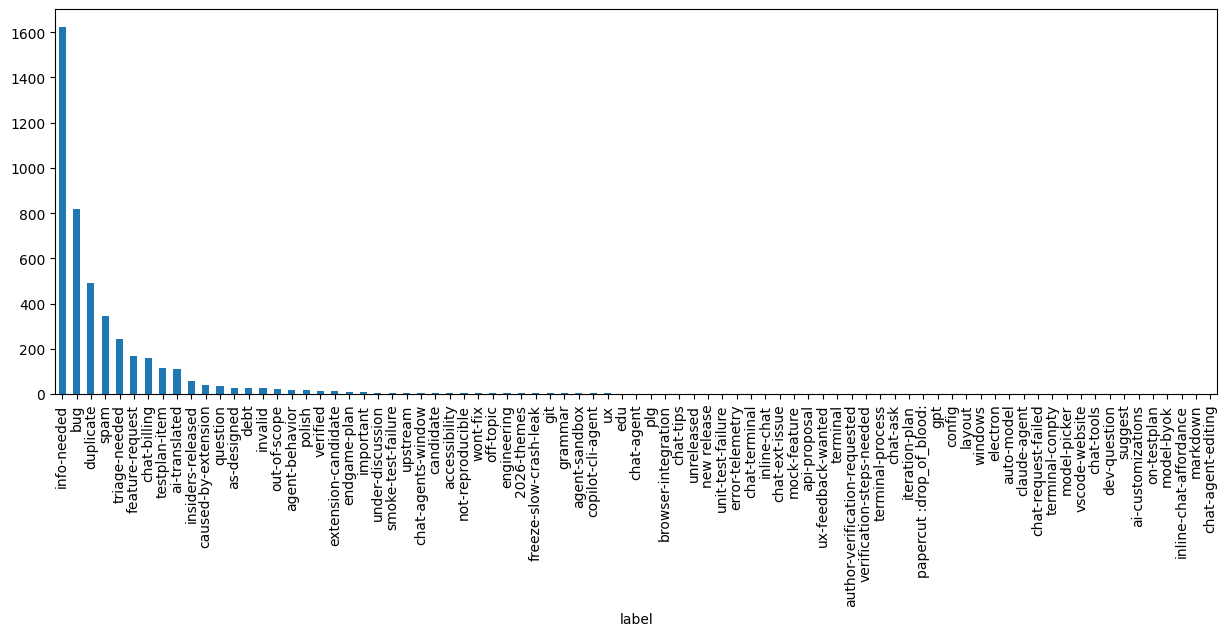

In [11]:
plt.figure(figsize=(15,5))
plt.fontsize=14
df["label"].value_counts().plot(kind="bar")

In [12]:
def label_mapping(label):
    if label in ["spam","invalid"]:
        return "Spam"
    elif label in ["bug","duplicate","caused-by-extension","freeze-slow-crash-leak","unit-test-failure"]:
        return "Bug"
    elif label in ["info-needed","question","author-verification-requested"]:
        return "Support"
    else:
        return None


In [13]:
df["label"]=df["label"].map(label_mapping)

label
Support    1656
Bug        1358
Spam        371
Name: count, dtype: int64


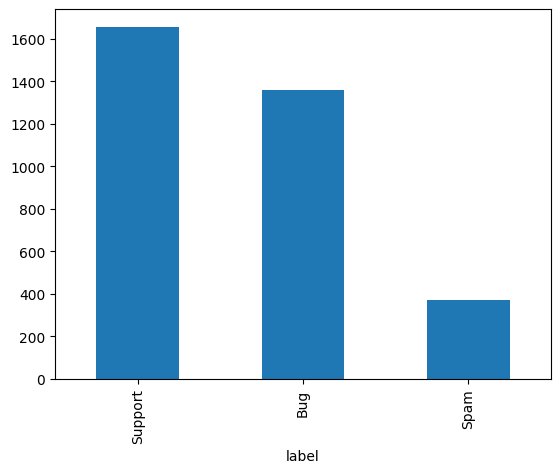

In [14]:
df["label"].value_counts().plot(kind="bar")
print(df["label"].value_counts())

In [15]:
df.isna().sum()

title       0
body        0
label    1141
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.shape

(3385, 3)

In [18]:
df["Text"]=df["title"]+" "+df["body"]
df.drop(columns=["title","body"],inplace=True)

In [19]:
df

,label,Text
2,Bug,[Unhandled Error] Uncaught TypeError: Cannot r...
5,Spam,Rate-limited whilst using agent to apply code ...
6,Support,Copilot not working \nType: <b>Bug</b>\n\nGith...
9,Spam,report issue <!-- ⚠️⚠️ Do Not Delete This! bug...
10,Bug,IA must create files but didn't do \nType: <b>...
...,...,...
4909,Bug,Chat took too long to get ready. \nType: <b>Pe...
4910,Support,Chat took too long to get ready. \nType: <b>Pe...
4911,Bug,Integrated browser is rendered on top of sideb...
4912,Support,Not getting a pop-up for automatic tasks Testi...


In [20]:
df.duplicated().sum()

3

In [21]:
label_enc={"Spam":0,"Bug":1,"Support":2}
df["label"]=df["label"].map(label_enc)

In [22]:
from transformers import AutoTokenizer
model="distilbert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model)
from transformers import AutoModelForSequenceClassification

c:\Users\nice\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [23]:
import torch
import gc

def clear_gpu_memory():
    # 1. مسح المتغيرات غير المستخدمة من الرامات العادية
    gc.collect()
    
    # 2. تفضي الـ Cache بتاع الـ PyTorch من الـ GPU
    torch.cuda.empty_cache()
    
    # 3. (اختياري) لو عايز تتأكد إن كل حاجة اتمسحت فعلاً
    with torch.no_grad():
        torch.cuda.empty_cache()
        
    print("GPU memory cleared!")

# استدعي الفانكشن
clear_gpu_memory()

GPU memory cleared!


In [24]:
from datasets import Dataset
from torch import nn
import torch
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
df['label'] = df['label'].astype(int)
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df["label"])
train=Dataset.from_pandas(train_df)
test=Dataset.from_pandas(test_df)
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
def tokenize_function(examples):
    return tokenizer(examples["Text"], truncation=True)

tokenized_train=train.map(tokenize_function, batched=True)
tokenized_test=test.map(tokenize_function, batched=True)
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor([4.5, 1.2, 1], device=model.device) 
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss
    
tokenized_train.set_format("torch", columns=["input_ids","attention_mask","label"])
tokenized_test.set_format("torch", columns=["input_ids","attention_mask","label"])
model=AutoModelForSequenceClassification.from_pretrained(model,num_labels=3)



Map:   0%|          | 0/2708 [00:00<?, ? examples/s]

Map:   0%|          | 0/677 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
training_args=TrainingArguments(
    output_dir="./results",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)
def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="weighted")
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}
trainer=CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.741666,0.583201,0.763663,0.766729,0.763663,0.762343
2,0.575657,0.552228,0.778434,0.779177,0.778434,0.778670
3,0.333405,0.446383,0.818316,0.820469,0.818316,0.818070
4,0.287959,0.537626,0.794682,0.797926,0.794682,0.794795
5,0.181280,0.728767,0.775480,0.778742,0.775480,0.774131
6,0.146461,0.755880,0.788774,0.789370,0.788774,0.788574


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1020, training_loss=0.3678013766805331, metrics={'train_runtime': 851.5258, 'train_samples_per_second': 19.081, 'train_steps_per_second': 1.198, 'total_flos': 2152368677117952.0, 'train_loss': 0.3678013766805331, 'epoch': 6.0})

In [30]:
def predict_issue(text):
    # 1. تجهيز النص
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    
    # 2. التوقع
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)
    pred_idx = probs.argmax().item()
    
    # 3. النتيجة
    labels = ["Spam 📩", "Bug 🐞", "Support/Info ℹ️"]
    return labels[pred_idx], probs[0][pred_idx].item()

# --- جرب جمل من عندك هنا ---
test_text = "I want to talk with support about an issue I'm facing"
label, confidence = predict_issue(test_text)

print(f"Text: {test_text}")
print(f"Prediction: {label} (Confidence: {confidence:.2%})")

Text: I want to talk with support about an issue I'm facing
Prediction: Support/Info ℹ️ (Confidence: 53.99%)


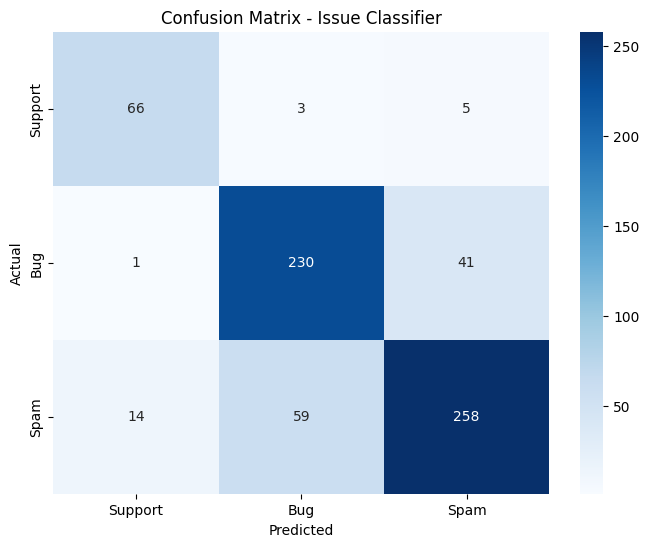

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. توقع النتائج للـ Test Set كاملة
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# 2. رسم الـ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Support', 'Bug', 'Spam'] # اتأكد من الترتيب حسب الـ IDs عندك

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Issue Classifier')
plt.show()

In [31]:
# 1. حفظ الموديل والـ Tokenizer في فولدر نهائي
model.save_pretrained("./final_issue_model")
tokenizer.save_pretrained("./final_issue_model")

# 2. تفريغ الـ GPU تماماً عشان لو هتعمل حاجة تانية
import torch
import gc
gc.collect()
torch.cuda.empty_cache()

print("Model saved and GPU memory is free!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved and GPU memory is free!
